In [1]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)

PyTorch: 2.14.1+cpu
OpenCV: 5.0.0


In [2]:
# Load the trained YOLO model
yolo_model = YOLO(
    "../runs/detect/results/yolo/retail_yolo11n/weights/best.pt"
)

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [3]:
print("YOLO classes:")
print(yolo_model.names)

YOLO classes:
{0: 'aqua', 1: 'chitato', 2: 'indomie', 3: 'pepsodent', 4: 'shampoo', 5: 'tissue'}


In [4]:
import os

test_image_dir = "../data/processed/yolo/images/test"

test_images = [
    f for f in os.listdir(test_image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of test images:", len(test_images))
print("First 10 images:")

for image_name in test_images[:10]:
    print(image_name)

Number of test images: 86
First 10 images:
aqua (1).jpg
aqua (10).jpg
aqua (2).jpg
aqua (3).jpg
aqua (4).jpg
aqua (5).jpg
aqua (6).jpg
aqua (7).jpg
aqua (8).jpg
aqua (9).jpg


In [5]:
shelf_image_path = os.path.join(
    test_image_dir,
    test_images[0]
)

print("Selected image:")
print(shelf_image_path)

Selected image:
../data/processed/yolo/images/test\aqua (1).jpg


In [6]:
shelf_image_path = os.path.join(
    test_image_dir,
    test_images[0]
)

print("Selected image:")
print(shelf_image_path)

Selected image:
../data/processed/yolo/images/test\aqua (1).jpg


In [7]:
results_yolo = yolo_model.predict(
    source=shelf_image_path,
    imgsz=416,
    conf=0.25,
    device="cpu",
    verbose=False
)

print("YOLO detection completed!")

YOLO detection completed!


In [8]:
result = results_yolo[0]

if result.boxes is not None:
    number_of_detections = len(result.boxes)
else:
    number_of_detections = 0

print("Number of detected products:", number_of_detections)

Number of detected products: 1


In [9]:
if number_of_detections > 0:

    detected_classes = result.boxes.cls.cpu().numpy().astype(int)
    detected_confidences = result.boxes.conf.cpu().numpy()

    for i, (class_id, confidence) in enumerate(
        zip(detected_classes, detected_confidences),
        start=1
    ):
        class_name = yolo_model.names[class_id]

        print(
            f"Detection {i}: "
            f"{class_name} | "
            f"Confidence: {confidence * 100:.2f}%"
        )

else:
    print("No products detected.")

Detection 1: aqua | Confidence: 89.99%


In [10]:
# Get bounding boxes
boxes = result.boxes.xyxy.cpu().numpy()

print("Bounding boxes:")
print(boxes)

Bounding boxes:
[[     192.71       146.3       252.6      328.08]]


In [12]:
# Reload the selected image
shelf_image = cv2.imread(shelf_image_path)

if shelf_image is None:
    print("Image could not be loaded.")
else:
    print("Shelf image loaded successfully!")
    print("Shape:", shelf_image.shape)

Shelf image loaded successfully!
Shape: (512, 512, 3)


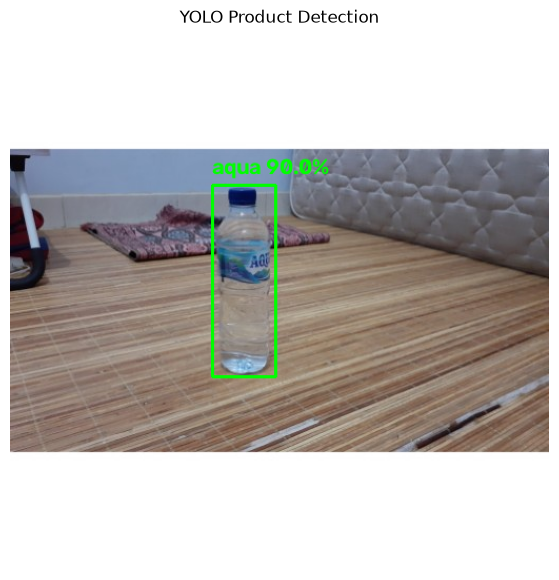

In [13]:
# Make a copy of the original image
detection_image = shelf_image.copy()

for box, class_id, confidence in zip(
    result.boxes.xyxy.cpu().numpy(),
    result.boxes.cls.cpu().numpy().astype(int),
    result.boxes.conf.cpu().numpy()
):

    x1, y1, x2, y2 = box.astype(int)

    class_name = yolo_model.names[class_id]

    label = f"{class_name} {confidence * 100:.1f}%"

    # Draw bounding box
    cv2.rectangle(
        detection_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    cv2.putText(
        detection_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )

# Convert BGR → RGB
detection_image_rgb = cv2.cvtColor(
    detection_image,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(10, 7))
plt.imshow(detection_image_rgb)
plt.axis("off")
plt.title("YOLO Product Detection")
plt.show()

In [14]:
results_yolo = yolo_model.predict(
    source=shelf_image_path,
    imgsz=416,
    conf=0.25,
    device="cpu",
    verbose=False
)

result = results_yolo[0]

print("YOLO detection completed!")

YOLO detection completed!


In [15]:
from collections import Counter

# Get detected class IDs
detected_class_ids = (
    result.boxes.cls.cpu()
    .numpy()
    .astype(int)
)

# Convert class IDs to product names
detected_product_names = [
    yolo_model.names[class_id]
    for class_id in detected_class_ids
]

# Count each product
product_counts = Counter(detected_product_names)

print("Product counts:")

for product in yolo_model.names.values():
    count = product_counts.get(product, 0)
    print(f"{product:10s}: {count}")

print("\nTotal detected products:", len(detected_product_names))

Product counts:
aqua      : 1
chitato   : 0
indomie   : 0
pepsodent : 0
shampoo   : 0
tissue    : 0

Total detected products: 1


In [16]:
# Get the first detected bounding box
box = result.boxes.xyxy[0].cpu().numpy()

x1, y1, x2, y2 = box.astype(int)

# Crop the product from the original image
product_crop = shelf_image[y1:y2, x1:x2]

print("Crop shape:", product_crop.shape)

Crop shape: (182, 60, 3)


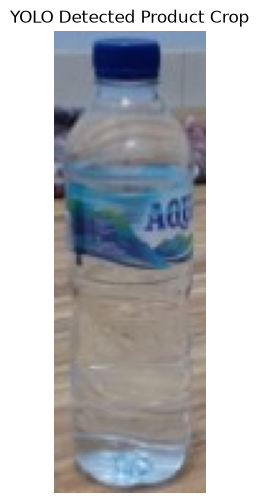

In [17]:
# Convert BGR → RGB
product_crop_rgb = cv2.cvtColor(
    product_crop,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(4, 6))
plt.imshow(product_crop_rgb)
plt.axis("off")
plt.title("YOLO Detected Product Crop")
plt.show()

In [18]:
class RetailCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [19]:
device = torch.device("cpu")

class_names = [
    "aqua",
    "chitato",
    "indomie",
    "pepsodent",
    "shampoo",
    "tissue"
]

classifier_model = RetailCNN(num_classes=6)
classifier_model = classifier_model.to(device)

classifier_model.load_state_dict(
    torch.load(
        "../models/retail_cnn_pytorch_best.pth",
        map_location=device
    )
)

classifier_model.eval()

print("PyTorch CNN loaded successfully!")

PyTorch CNN loaded successfully!


In [21]:
# Convert BGR → RGB
crop_rgb = cv2.cvtColor(product_crop, cv2.COLOR_BGR2RGB)

# Resize
crop_resized = cv2.resize(
    crop_rgb,
    (224, 224)
)

# Gaussian blur
crop_blurred = cv2.GaussianBlur(
    crop_resized,
    (3, 3),
    0
)

# RGB → LAB
crop_lab = cv2.cvtColor(
    crop_blurred,
    cv2.COLOR_RGB2LAB
)

# Split LAB channels
lab_channels = list(cv2.split(crop_lab))

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

lab_channels[0] = clahe.apply(lab_channels[0])

# Merge channels
crop_lab = cv2.merge(lab_channels)

# LAB → RGB
crop_processed = cv2.cvtColor(
    crop_lab,
    cv2.COLOR_LAB2RGB
)

print("Processed crop shape:", crop_processed.shape)
print("Processed crop dtype:", crop_processed.dtype)

Processed crop shape: (224, 224, 3)
Processed crop dtype: uint8


In [22]:
crop_tensor = torch.from_numpy(
    crop_processed
).permute(2, 0, 1).float() / 255.0

crop_tensor = crop_tensor.unsqueeze(0)
crop_tensor = crop_tensor.to(device)

print("Tensor shape:", crop_tensor.shape)
print("Tensor dtype:", crop_tensor.dtype)

Tensor shape: torch.Size([1, 3, 224, 224])
Tensor dtype: torch.float32


In [23]:
with torch.no_grad():
    outputs = classifier_model(crop_tensor)
    probabilities = torch.softmax(outputs, dim=1)

predicted_class_id = torch.argmax(
    probabilities,
    dim=1
).item()

predicted_class = class_names[predicted_class_id]

confidence = probabilities[
    0, predicted_class_id
].item()

print("PyTorch prediction:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

PyTorch prediction: aqua
Confidence: 99.04%


In [24]:
# YOLO result
yolo_class_id = int(result.boxes.cls[0].cpu().item())
yolo_class = yolo_model.names[yolo_class_id]

yolo_confidence = float(
    result.boxes.conf[0].cpu().item()
)

# PyTorch result
cnn_class = predicted_class
cnn_confidence = confidence

print("YOLO Detection")
print("------------------------")
print(f"Product: {yolo_class}")
print(f"Confidence: {yolo_confidence * 100:.2f}%")

print("\nPyTorch Classification")
print("------------------------")
print(f"Product: {cnn_class}")
print(f"Confidence: {cnn_confidence * 100:.2f}%")

print("\nCombined Result")
print("------------------------")

if yolo_class == cnn_class:
    print("✓ Models agree")
    print(f"Final product: {cnn_class}")
else:
    print("⚠ Models disagree")
    print(f"YOLO: {yolo_class}")
    print(f"PyTorch: {cnn_class}")

YOLO Detection
------------------------
Product: aqua
Confidence: 89.99%

PyTorch Classification
------------------------
Product: aqua
Confidence: 99.04%

Combined Result
------------------------
✓ Models agree
Final product: aqua


In [25]:
from collections import Counter

inventory_results = []

# Process every YOLO detection
for i, box in enumerate(result.boxes.xyxy.cpu().numpy()):

    # -----------------------------
    # 1. Get YOLO information
    # -----------------------------
    x1, y1, x2, y2 = box.astype(int)

    yolo_class_id = int(
        result.boxes.cls[i].cpu().item()
    )

    yolo_class = yolo_model.names[yolo_class_id]

    yolo_confidence = float(
        result.boxes.conf[i].cpu().item()
    )

    # -----------------------------
    # 2. Crop product
    # -----------------------------
    product_crop = shelf_image[y1:y2, x1:x2]

    # -----------------------------
    # 3. OpenCV preprocessing
    # -----------------------------
    crop_rgb = cv2.cvtColor(
        product_crop,
        cv2.COLOR_BGR2RGB
    )

    crop_resized = cv2.resize(
        crop_rgb,
        (224, 224)
    )

    crop_blurred = cv2.GaussianBlur(
        crop_resized,
        (3, 3),
        0
    )

    crop_lab = cv2.cvtColor(
        crop_blurred,
        cv2.COLOR_RGB2LAB
    )

    lab_channels = list(
        cv2.split(crop_lab)
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    lab_channels[0] = clahe.apply(
        lab_channels[0]
    )

    crop_lab = cv2.merge(
        lab_channels
    )

    crop_processed = cv2.cvtColor(
        crop_lab,
        cv2.COLOR_LAB2RGB
    )

    # -----------------------------
    # 4. Convert to PyTorch tensor
    # -----------------------------
    crop_tensor = torch.from_numpy(
        crop_processed
    ).permute(2, 0, 1).float() / 255.0

    crop_tensor = crop_tensor.unsqueeze(0)
    crop_tensor = crop_tensor.to(device)

    # -----------------------------
    # 5. PyTorch classification
    # -----------------------------
    with torch.no_grad():
        outputs = classifier_model(
            crop_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

    cnn_class_id = torch.argmax(
        probabilities,
        dim=1
    ).item()

    cnn_class = class_names[
        cnn_class_id
    ]

    cnn_confidence = probabilities[
        0, cnn_class_id
    ].item()

    # -----------------------------
    # 6. Compare both models
    # -----------------------------
    models_agree = (
        yolo_class == cnn_class
    )

    # -----------------------------
    # 7. Store result
    # -----------------------------
    inventory_results.append({
        "detection_id": i + 1,
        "yolo_product": yolo_class,
        "yolo_confidence": yolo_confidence,
        "cnn_product": cnn_class,
        "cnn_confidence": cnn_confidence,
        "models_agree": models_agree,
        "final_product": cnn_class
    })

print("Inventory processing completed!")

for item in inventory_results:
    print(
        f"Detection {item['detection_id']}: "
        f"{item['final_product']} | "
        f"YOLO: {item['yolo_confidence'] * 100:.2f}% | "
        f"CNN: {item['cnn_confidence'] * 100:.2f}% | "
        f"Agree: {item['models_agree']}"
    )

Inventory processing completed!
Detection 1: aqua | YOLO: 89.99% | CNN: 99.04% | Agree: True


In [26]:
final_products = [
    item["final_product"]
    for item in inventory_results
]

final_inventory = Counter(
    final_products
)

print("Final Product Inventory")
print("========================")

for product in class_names:
    count = final_inventory.get(
        product,
        0
    )

    print(
        f"{product:10s}: {count}"
    )

print(
    "\nTotal products:",
    len(final_products)
)

Final Product Inventory
aqua      : 1
chitato   : 0
indomie   : 0
pepsodent : 0
shampoo   : 0
tissue    : 0

Total products: 1


In [27]:
# Create a copy of the original shelf image
final_image = shelf_image.copy()

# Draw every detected product
for item, box in zip(
    inventory_results,
    result.boxes.xyxy.cpu().numpy()
):

    x1, y1, x2, y2 = box.astype(int)

    final_product = item["final_product"]
    yolo_conf = item["yolo_confidence"]
    cnn_conf = item["cnn_confidence"]

    # Draw bounding box
    cv2.rectangle(
        final_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Label
    label = (
        f"{final_product} | "
        f"YOLO {yolo_conf * 100:.1f}% | "
        f"CNN {cnn_conf * 100:.1f}%"
    )

    # Put label above bounding box
    cv2.putText(
        final_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

In [28]:
# Add inventory summary to the image

summary_y = 30

cv2.putText(
    final_image,
    "Shelf Inventory",
    (10, summary_y),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

summary_y += 30

for product in class_names:

    count = final_inventory.get(
        product,
        0
    )

    text = f"{product}: {count}"

    cv2.putText(
        final_image,
        text,
        (10, summary_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA
    )

    summary_y += 22

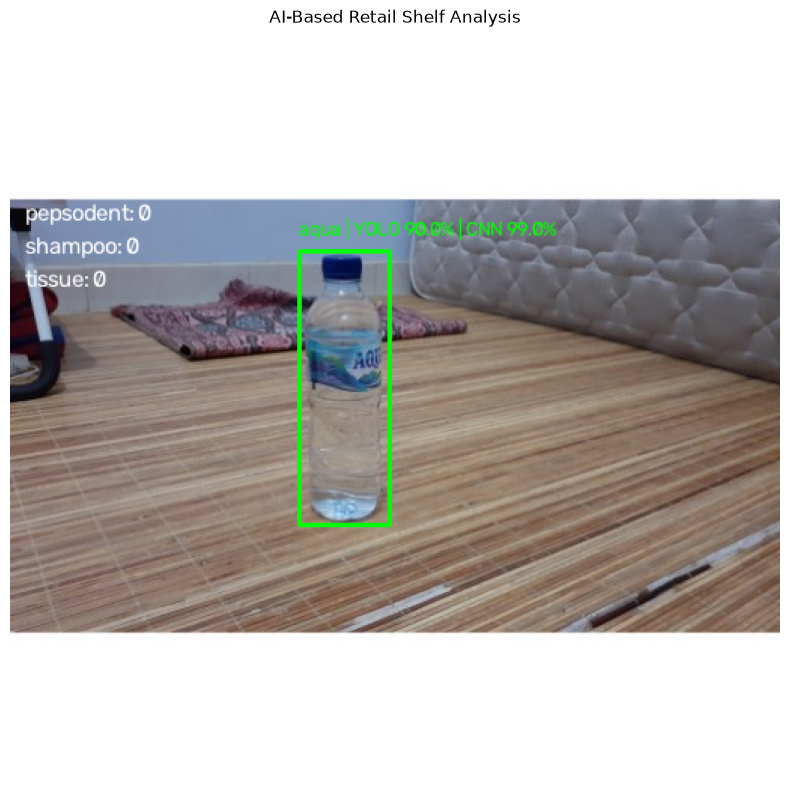

In [29]:
# Convert BGR → RGB for Matplotlib
final_image_rgb = cv2.cvtColor(
    final_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 10))

plt.imshow(final_image_rgb)
plt.axis("off")
plt.title("AI-Based Retail Shelf Analysis")

plt.show()

In [30]:
import os

test_dir = "../data/processed/yolo/images/test"

test_image_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

# Test the first 10 images
selected_test_images = test_image_files[:10]

print("Images selected for testing:")
for image_name in selected_test_images:
    print(image_name)

print("\nTotal images:", len(selected_test_images))

Images selected for testing:
aqua (1).jpg
aqua (10).jpg
aqua (2).jpg
aqua (3).jpg
aqua (4).jpg
aqua (5).jpg
aqua (6).jpg
aqua (7).jpg
aqua (8).jpg
aqua (9).jpg

Total images: 10


In [31]:
def analyze_shelf_image(image_path):

    # Load image
    image = cv2.imread(image_path)

    # YOLO detection
    results = yolo_model.predict(
        source=image,
        imgsz=416,
        conf=0.25,
        device="cpu",
        verbose=False
    )

    result = results[0]

    inventory_results = []

    # Process every detection
    for i, box in enumerate(
        result.boxes.xyxy.cpu().numpy()
    ):

        x1, y1, x2, y2 = box.astype(int)

        # YOLO information
        yolo_class_id = int(
            result.boxes.cls[i].cpu().item()
        )

        yolo_class = yolo_model.names[
            yolo_class_id
        ]

        yolo_confidence = float(
            result.boxes.conf[i].cpu().item()
        )

        # Crop
        product_crop = image[
            y1:y2,
            x1:x2
        ]

        if product_crop.size == 0:
            continue

        # OpenCV preprocessing
        crop_rgb = cv2.cvtColor(
            product_crop,
            cv2.COLOR_BGR2RGB
        )

        crop_resized = cv2.resize(
            crop_rgb,
            (224, 224)
        )

        crop_blurred = cv2.GaussianBlur(
            crop_resized,
            (3, 3),
            0
        )

        crop_lab = cv2.cvtColor(
            crop_blurred,
            cv2.COLOR_RGB2LAB
        )

        lab_channels = list(
            cv2.split(crop_lab)
        )

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

        lab_channels[0] = clahe.apply(
            lab_channels[0]
        )

        crop_lab = cv2.merge(
            lab_channels
        )

        crop_processed = cv2.cvtColor(
            crop_lab,
            cv2.COLOR_LAB2RGB
        )

        # Tensor
        crop_tensor = torch.from_numpy(
            crop_processed
        ).permute(2, 0, 1).float() / 255.0

        crop_tensor = crop_tensor.unsqueeze(0)
        crop_tensor = crop_tensor.to(device)

        # CNN classification
        with torch.no_grad():

            outputs = classifier_model(
                crop_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

        cnn_class_id = torch.argmax(
            probabilities,
            dim=1
        ).item()

        cnn_class = class_names[
            cnn_class_id
        ]

        cnn_confidence = probabilities[
            0,
            cnn_class_id
        ].item()

        # Agreement
        models_agree = (
            yolo_class == cnn_class
        )

        inventory_results.append({
            "yolo_product": yolo_class,
            "yolo_confidence": yolo_confidence,
            "cnn_product": cnn_class,
            "cnn_confidence": cnn_confidence,
            "models_agree": models_agree,
            "final_product": cnn_class
        })

    return inventory_results

In [32]:
all_test_results = []

for image_name in selected_test_images:

    image_path = os.path.join(
        test_dir,
        image_name
    )

    results = analyze_shelf_image(
        image_path
    )

    all_test_results.append({
        "image": image_name,
        "detections": len(results),
        "results": results
    })

print("Multi-image testing completed!")

Multi-image testing completed!


In [33]:
for item in all_test_results:

    print("\n" + "=" * 60)
    print("Image:", item["image"])
    print("Detected products:", item["detections"])

    for i, result_item in enumerate(
        item["results"],
        start=1
    ):

        print(
            f"  Product {i}: "
            f"{result_item['final_product']} | "
            f"YOLO: "
            f"{result_item['yolo_confidence'] * 100:.1f}% | "
            f"CNN: "
            f"{result_item['cnn_confidence'] * 100:.1f}% | "
            f"Agreement: "
            f"{result_item['models_agree']}"
        )


Image: aqua (1).jpg
Detected products: 1
  Product 1: aqua | YOLO: 90.0% | CNN: 99.0% | Agreement: True

Image: aqua (10).jpg
Detected products: 1
  Product 1: shampoo | YOLO: 99.5% | CNN: 57.2% | Agreement: False

Image: aqua (2).jpg
Detected products: 1
  Product 1: aqua | YOLO: 88.1% | CNN: 100.0% | Agreement: True

Image: aqua (3).jpg
Detected products: 1
  Product 1: aqua | YOLO: 92.4% | CNN: 99.9% | Agreement: True

Image: aqua (4).jpg
Detected products: 1
  Product 1: aqua | YOLO: 96.1% | CNN: 100.0% | Agreement: True

Image: aqua (5).jpg
Detected products: 1
  Product 1: aqua | YOLO: 89.1% | CNN: 99.8% | Agreement: True

Image: aqua (6).jpg
Detected products: 1
  Product 1: aqua | YOLO: 98.7% | CNN: 92.4% | Agreement: True

Image: aqua (7).jpg
Detected products: 1
  Product 1: aqua | YOLO: 98.8% | CNN: 98.6% | Agreement: True

Image: aqua (8).jpg
Detected products: 1
  Product 1: aqua | YOLO: 99.3% | CNN: 99.9% | Agreement: True

Image: aqua (9).jpg
Detected products: 1
  Prod

In [34]:
total_images = len(all_test_results)

total_detections = sum(
    item["detections"]
    for item in all_test_results
)

total_agreements = 0
total_disagreements = 0

for item in all_test_results:
    for result_item in item["results"]:

        if result_item["models_agree"]:
            total_agreements += 1
        else:
            total_disagreements += 1

print("COMBINED PIPELINE TEST SUMMARY")
print("=" * 40)

print("Images tested:", total_images)
print("Total products detected:", total_detections)
print("Model agreements:", total_agreements)
print("Model disagreements:", total_disagreements)

if total_detections > 0:
    agreement_rate = (
        total_agreements / total_detections
    ) * 100

    print(
        f"Agreement rate: {agreement_rate:.2f}%"
    )

COMBINED PIPELINE TEST SUMMARY
Images tested: 10
Total products detected: 10
Model agreements: 9
Model disagreements: 1
Agreement rate: 90.00%


In [35]:
import pandas as pd

summary_rows = []

for item in all_test_results:

    for detection_id, result_item in enumerate(
        item["results"],
        start=1
    ):

        summary_rows.append({
            "Image": item["image"],
            "Detection": detection_id,
            "YOLO Product": result_item["yolo_product"],
            "YOLO Confidence (%)": round(
                result_item["yolo_confidence"] * 100,
                2
            ),
            "CNN Product": result_item["cnn_product"],
            "CNN Confidence (%)": round(
                result_item["cnn_confidence"] * 100,
                2
            ),
            "Agreement": result_item["models_agree"],
            "Final Product": result_item["final_product"]
        })

results_df = pd.DataFrame(summary_rows)

display(results_df)

,Image,Detection,YOLO Product,YOLO Confidence (%),CNN Product,CNN Confidence (%),Agreement,Final Product
0,aqua (1).jpg,1,aqua,89.99,aqua,99.04,True,aqua
1,aqua (10).jpg,1,aqua,99.49,shampoo,57.18,False,shampoo
2,aqua (2).jpg,1,aqua,88.12,aqua,99.98,True,aqua
3,aqua (3).jpg,1,aqua,92.42,aqua,99.95,True,aqua
4,aqua (4).jpg,1,aqua,96.12,aqua,99.96,True,aqua
5,aqua (5).jpg,1,aqua,89.15,aqua,99.82,True,aqua
6,aqua (6).jpg,1,aqua,98.67,aqua,92.44,True,aqua
7,aqua (7).jpg,1,aqua,98.82,aqua,98.59,True,aqua
8,aqua (8).jpg,1,aqua,99.25,aqua,99.89,True,aqua
9,aqua (9).jpg,1,aqua,99.34,aqua,58.96,True,aqua


In [36]:
from collections import defaultdict

# Group test images by product class
images_by_class = defaultdict(list)

for image_name in test_image_files:

    product_name = image_name.split(" ")[0].lower()

    if product_name in class_names:
        images_by_class[product_name].append(
            image_name
        )

# Select up to 5 images from each class
balanced_test_images = []

for product in class_names:

    selected = images_by_class[product][:5]

    balanced_test_images.extend(
        selected
    )

print("Balanced test set")
print("=" * 40)

for product in class_names:
    count = sum(
        1 for image in balanced_test_images
        if image.split(" ")[0].lower() == product
    )

    print(f"{product:10s}: {count}")

print("\nTotal images:", len(balanced_test_images))

Balanced test set
aqua      : 5
chitato   : 5
indomie   : 5
pepsodent : 5
shampoo   : 5
tissue    : 5

Total images: 30


In [37]:
balanced_results = []

for image_name in balanced_test_images:

    image_path = os.path.join(
        test_dir,
        image_name
    )

    results = analyze_shelf_image(
        image_path
    )

    balanced_results.append({
        "image": image_name,
        "results": results
    })

print("30-image all-class pipeline test completed!")

30-image all-class pipeline test completed!


In [38]:
total_images = len(balanced_results)
total_detections = 0
total_agreements = 0
total_disagreements = 0

for item in balanced_results:

    total_detections += len(
        item["results"]
    )

    for result_item in item["results"]:

        if result_item["models_agree"]:
            total_agreements += 1
        else:
            total_disagreements += 1

print("ALL-CLASS PIPELINE TEST")
print("=" * 40)

print("Images tested:", total_images)
print("Products detected:", total_detections)
print("Model agreements:", total_agreements)
print("Model disagreements:", total_disagreements)

if total_detections > 0:

    agreement_rate = (
        total_agreements /
        total_detections
    ) * 100

    print(
        f"Agreement rate: {agreement_rate:.2f}%"
    )

ALL-CLASS PIPELINE TEST
Images tested: 30
Products detected: 31
Model agreements: 24
Model disagreements: 7
Agreement rate: 77.42%


In [39]:
correct_predictions = 0
incorrect_predictions = 0

class_results = {
    product: {
        "correct": 0,
        "total": 0
    }
    for product in class_names
}

for item in balanced_results:

    image_name = item["image"]

    # Ground-truth class from filename
    actual_product = image_name.split(" ")[0].lower()

    for result_item in item["results"]:

        predicted_product = result_item[
            "final_product"
        ]

        class_results[actual_product]["total"] += 1

        if predicted_product == actual_product:

            correct_predictions += 1
            class_results[actual_product]["correct"] += 1

        else:

            incorrect_predictions += 1

print("COMBINED PIPELINE ACCURACY")
print("=" * 40)

print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

if total_detections > 0:

    pipeline_accuracy = (
        correct_predictions /
        total_detections
    ) * 100

    print(
        f"Pipeline accuracy: "
        f"{pipeline_accuracy:.2f}%"
    )

COMBINED PIPELINE ACCURACY
Correct predictions: 24
Incorrect predictions: 7
Pipeline accuracy: 77.42%


In [40]:
print("PER-CLASS PIPELINE RESULTS")
print("=" * 40)

for product in class_names:

    correct = class_results[product]["correct"]
    total = class_results[product]["total"]

    if total > 0:
        accuracy = (
            correct / total
        ) * 100
    else:
        accuracy = 0

    print(
        f"{product:10s}: "
        f"{correct}/{total} "
        f"({accuracy:.2f}%)"
    )

PER-CLASS PIPELINE RESULTS
aqua      : 4/5 (80.00%)
chitato   : 3/5 (60.00%)
indomie   : 4/5 (80.00%)
pepsodent : 4/6 (66.67%)
shampoo   : 4/5 (80.00%)
tissue    : 5/5 (100.00%)


In [41]:
print("INCORRECT PIPELINE PREDICTIONS")
print("=" * 70)

error_count = 0

for item in balanced_results:

    image_name = item["image"]
    actual_product = image_name.split(" ")[0].lower()

    for detection_id, result_item in enumerate(
        item["results"],
        start=1
    ):

        predicted_product = result_item["final_product"]

        if predicted_product != actual_product:

            error_count += 1

            print(
                f"\nError {error_count}"
            )

            print(
                f"Image: {image_name}"
            )

            print(
                f"Detection: {detection_id}"
            )

            print(
                f"Actual: {actual_product}"
            )

            print(
                f"YOLO: {result_item['yolo_product']} "
                f"({result_item['yolo_confidence'] * 100:.2f}%)"
            )

            print(
                f"CNN: {result_item['cnn_product']} "
                f"({result_item['cnn_confidence'] * 100:.2f}%)"
            )

            print(
                f"Final: {result_item['final_product']}"
            )

            print(
                f"Agreement: "
                f"{result_item['models_agree']}"
            )

print(
    f"\nTotal errors: {error_count}"
)

INCORRECT PIPELINE PREDICTIONS

Error 1
Image: aqua (10).jpg
Detection: 1
Actual: aqua
YOLO: aqua (99.49%)
CNN: shampoo (57.18%)
Final: shampoo
Agreement: False

Error 2
Image: chitato (4).jpg
Detection: 1
Actual: chitato
YOLO: chitato (92.08%)
CNN: indomie (39.37%)
Final: indomie
Agreement: False

Error 3
Image: chitato (4).jpg
Detection: 2
Actual: chitato
YOLO: chitato (33.15%)
CNN: aqua (98.64%)
Final: aqua
Agreement: False

Error 4
Image: indomie (1).jpg
Detection: 1
Actual: indomie
YOLO: indomie (98.88%)
CNN: aqua (86.92%)
Final: aqua
Agreement: False

Error 5
Image: pepsodent (3).jpg
Detection: 1
Actual: pepsodent
YOLO: pepsodent (93.91%)
CNN: shampoo (94.19%)
Final: shampoo
Agreement: False

Error 6
Image: pepsodent (3).jpg
Detection: 2
Actual: pepsodent
YOLO: pepsodent (28.54%)
CNN: shampoo (78.12%)
Final: shampoo
Agreement: False

Error 7
Image: shampoo (10).jpg
Detection: 1
Actual: shampoo
YOLO: shampoo (94.98%)
CNN: indomie (55.87%)
Final: indomie
Agreement: False

Total err

In [42]:
# Final Phase 13 evaluation summary

print("=" * 60)
print("PHASE 13 — FINAL SHELF ANALYSIS RESULTS")
print("=" * 60)

print("\nDetection / Classification Pipeline")
print("----------------------------------------")
print(f"Images tested:          {total_images}")
print(f"Products detected:      {total_detections}")
print(f"Correct predictions:    {correct_predictions}")
print(f"Incorrect predictions:  {incorrect_predictions}")

print(
    f"\nPipeline accuracy:      "
    f"{pipeline_accuracy:.2f}%"
)

print(
    f"Model agreement rate:   "
    f"{agreement_rate:.2f}%"
)

print("\nPer-Class Results")
print("----------------------------------------")

for product in class_names:

    correct = class_results[product]["correct"]
    total = class_results[product]["total"]

    accuracy = (
        correct / total * 100
        if total > 0
        else 0
    )

    print(
        f"{product:10s}: "
        f"{correct}/{total} "
        f"({accuracy:.2f}%)"
    )

print("\nModel Performance")
print("----------------------------------------")
print("YOLO11n Test mAP50:     79.30%")
print("PyTorch CNN Test Acc:   76.39%")
print("Keras CNN Test Acc:     73.15%")

print("\nPhase 13 Status: COMPLETE")

PHASE 13 — FINAL SHELF ANALYSIS RESULTS

Detection / Classification Pipeline
----------------------------------------
Images tested:          30
Products detected:      31
Correct predictions:    24
Incorrect predictions:  7

Pipeline accuracy:      77.42%
Model agreement rate:   77.42%

Per-Class Results
----------------------------------------
aqua      : 4/5 (80.00%)
chitato   : 3/5 (60.00%)
indomie   : 4/5 (80.00%)
pepsodent : 4/6 (66.67%)
shampoo   : 4/5 (80.00%)
tissue    : 5/5 (100.00%)

Model Performance
----------------------------------------
YOLO11n Test mAP50:     79.30%
PyTorch CNN Test Acc:   76.39%
Keras CNN Test Acc:     73.15%

Phase 13 Status: COMPLETE
